In [13]:
import pandas as pd
import numpy as np
elements_data = pd.read_csv("../data/raw/elements_data.csv",index_col=0,skiprows=4,header=[1])
elements_data = elements_data.iloc[1:]
elements_data = elements_data.rename(columns = {"symbol": "Symbol"})
mendeleev = pd.read_csv("../data/raw/periodic_table_from_wikipedia.csv")
mendeleev.drop(["Name","Group","Period","Density","Melting point","Boiling point","Abundance in Earth\'s crust","Origin","Phase at room temperature","Specific heat capacity","Block"],axis=1,inplace=True)
# mendeleev["Electronegativity"] = mendeleev["Electronegativity"].replace("–", "0")
# elements_data[elements_data["symbol"]["str"].isin(nancols)]
mendeleev["Standard atomic weight"] = mendeleev["Symbol"].map(
    elements_data.set_index("Symbol")["mass"]
).fillna(mendeleev["Standard atomic weight"])
elements_data.loc[116,"pold.2"] = 69.1
mendeleev.loc[86,"Electronegativity"] = 0.7
mendeleev.loc[81,"Electronegativity"] = 2.33
elements_data["vdw_radius2"] = np.nanmean(elements_data[["vdw_radius.4","vdw_radius.5"]].apply(pd.to_numeric),axis=1)
mendeleev = pd.merge(mendeleev,elements_data[["Symbol","cov_radius","vdw_radius2","at_radius","pold.2"]].apply(pd.to_numeric,errors="ignore"),how="left",on="Symbol")
mendeleev.loc[118,"pold.2"] = 10
mendeleev.loc[119,"pold.2"] = 4.50711
vdw_radius2 = pd.read_csv("../data/raw/vdw_radius2.csv")
mendeleev = pd.merge(mendeleev,vdw_radius2,how="left",on="Symbol",suffixes=('', '_fill'))
mendeleev["vdw_radius2"] = mendeleev["vdw_radius2"].combine_first(mendeleev["vdw_radius2_fill"])
mendeleev.drop(columns=["vdw_radius2_fill"], inplace=True)
fill_at_rad = {
    "Lr":1.553, "Rf":1.476, "Db":1.413, "Sg":1.36, "Bh":1.31, "Hs":1.266,
    "Mt":1.227, "Ds":1.221, "Rg":1.187, "Cn":1.126, "Nh":1.319, "Fl":1.215,
    "Mc":1.295, "Lv":1.212, "Ts":1.146, "Og":1.09, "Wa":1.425, "D":0.529192875
}

mendeleev["at_radius"] = mendeleev["at_radius"].fillna(mendeleev["Symbol"].map(fill_at_rad))
mendeleev

C:\Users\EleMANtrO\AppData\Local\Temp\ipykernel_16720\345978514.py:16: RuntimeWarning: Mean of empty slice
  elements_data["vdw_radius2"] = np.nanmean(elements_data[["vdw_radius.4","vdw_radius.5"]].apply(pd.to_numeric),axis=1)
C:\Users\EleMANtrO\AppData\Local\Temp\ipykernel_16720\345978514.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  mendeleev = pd.merge(mendeleev,elements_data[["Symbol","cov_radius","vdw_radius2","at_radius","pold.2"]].apply(pd.to_numeric,errors="ignore"),how="left",on="Symbol")


,Atomic number,Symbol,Standard atomic weight,Electronegativity,cov_radius,vdw_radius2,at_radius,pold.2
0,1,H,1.007975,2.2,0.31,3.0405,0.529193,4.50711
1,2,He,4.002602,–,0.28,2.3620,0.291000,1.38375
2,3,Li,6.9675,0.98,1.28,2.4510,1.586000,164.11250
3,4,Be,9.0121831,1.57,0.96,2.7450,1.040000,37.74000
4,5,B,10.8135,2.04,0.84,4.0515,0.776000,20.50000
...,...,...,...,...,...,...,...,...
115,116,Lv,293.20449,–,NaN,4.7090,1.212000,69.10000
116,117,Ts,292.20746,–,NaN,4.7500,1.146000,76.00000
117,118,Og,294.21392,–,NaN,4.7650,1.090000,58.00000
118,10,Wa,18.015,–,NaN,2.8500,1.425000,10.00000


In [14]:
mendeleev.to_csv("../data/raw/feature_table.csv")

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
def mutual_visualize(X):
    X_mi = X.copy()
    X_mi[['Standard atomic weight', 'Electronegativity']] = X_mi[['Standard atomic weight', 'Electronegativity']].apply(pd.to_numeric,errors="coerce")
    floats = mendeleev.select_dtypes(include=["float","int"]).columns.to_list()
    print(floats)
    X_mi.dropna(inplace = True)
    X_mi = X_mi[floats]
    n = X_mi.shape[1]
    mi_matrix = pd.DataFrame(np.zeros((n,n)))
    for i in range(n):
        for j in range(n):
            mi_matrix.iloc[i,j] = mutual_info_regression(X_mi.iloc[:,i].to_numpy().reshape(-1,1),X_mi.iloc[:,j].to_numpy().reshape(-1,1))
    mi_matrix.index = X_mi.columns
    mi_matrix.columns = X_mi.columns
    fig, ax = plt.subplots(figsize = (20,20))
    sns.heatmap(mi_matrix, annot = True, cmap = "coolwarm", linewidths=.5, fmt='.3f', ax=ax)
    plt.show()

# def compute_mi(X,y, display = False):
#     X = X.copy()
#     X = X.dropna()
#     y = X.pop(y)
#     print(X.shape)
#     mi = mutual_info_regression(X,y)
#     mi = pd.Series(mi, index = X.columns).sort_values(ascending = False)
#     if display:
#         print(mi)
#     return mi

# compute_mi(mendeleev[floats],"Specific heat capacity")

['Atomic number', 'cov_radius', 'vdw_radius2', 'at_radius', 'pold.2']


D:\pycharm\GraphProject\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
D:\pycharm\GraphProject\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
D:\pycharm\GraphProject\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
D:\pycharm\GraphProject\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape

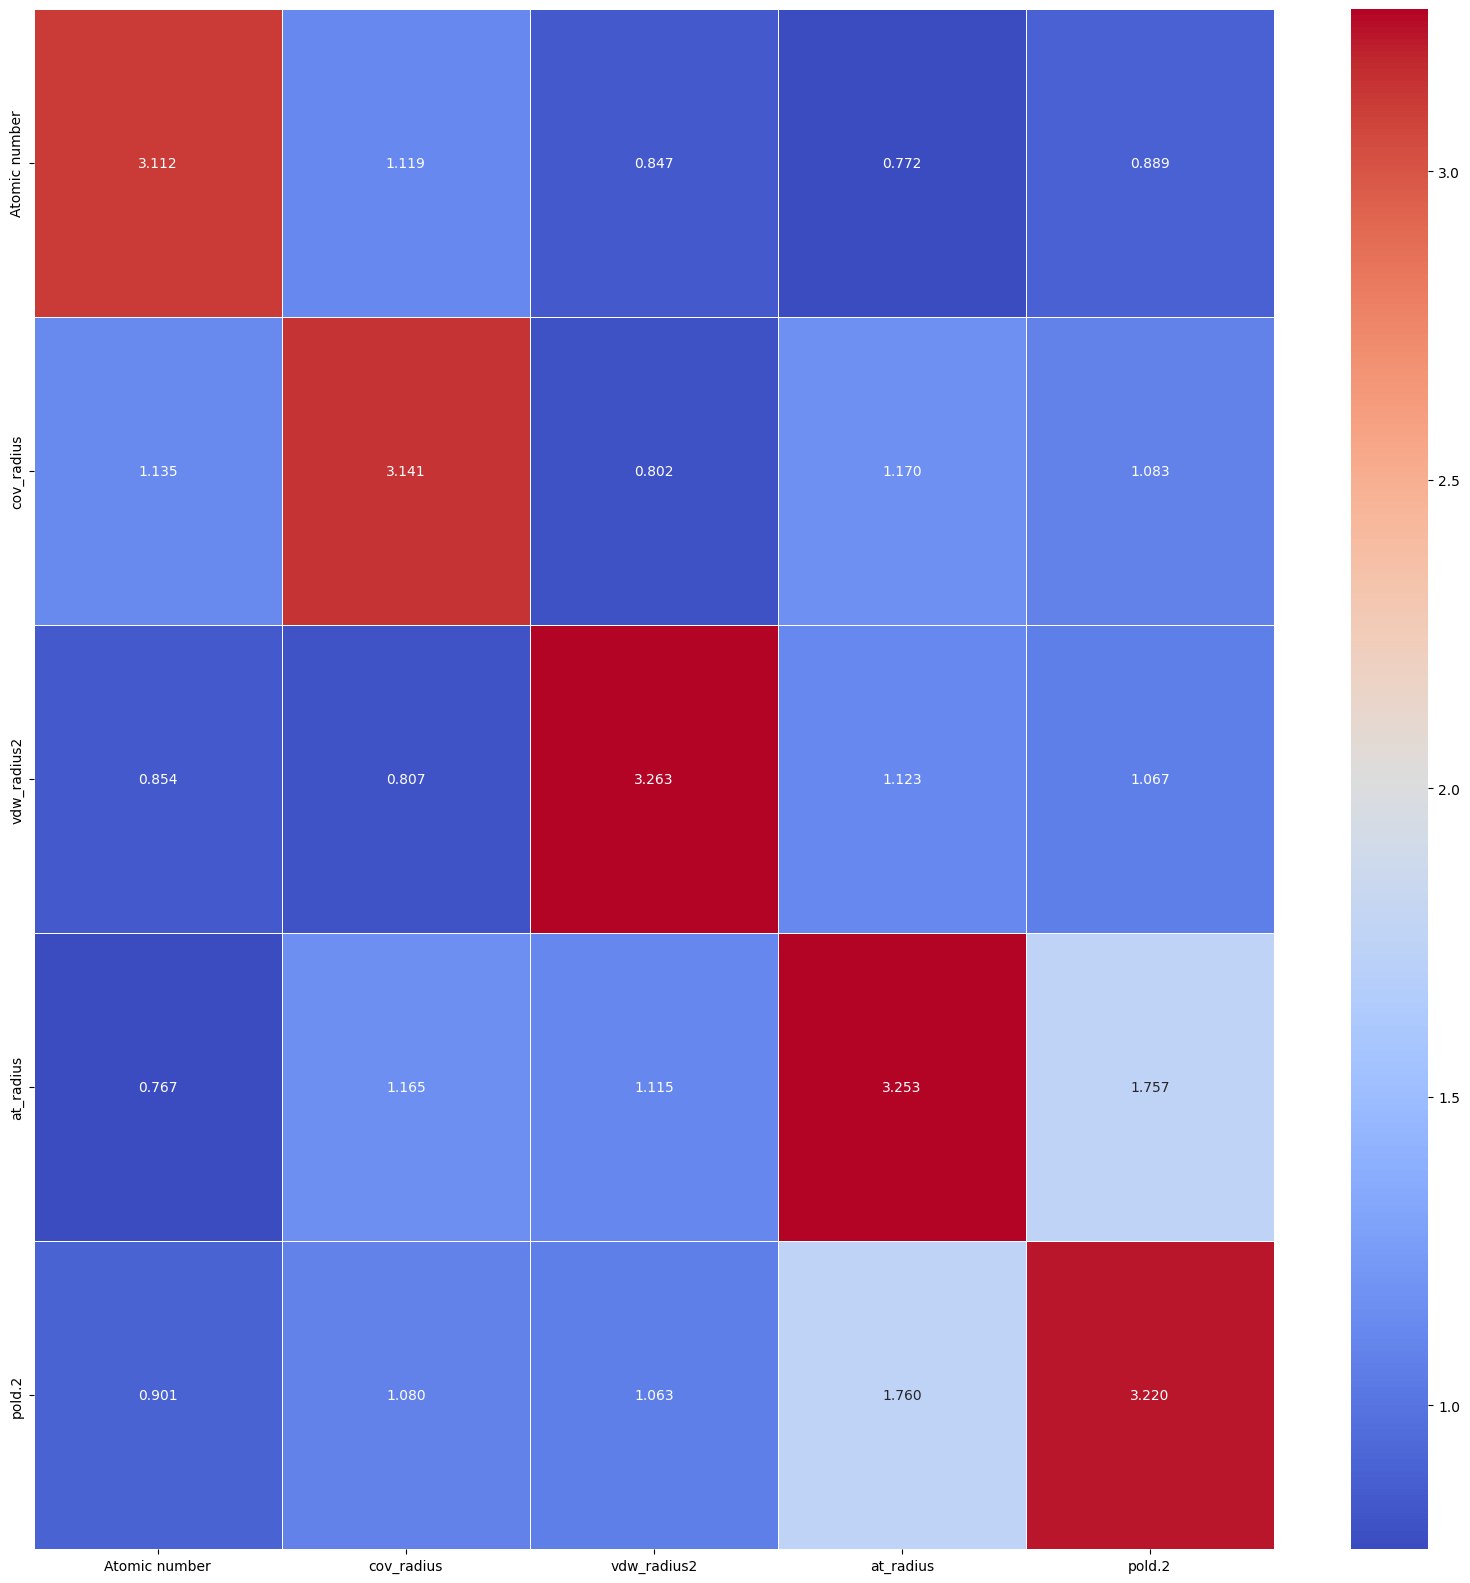

In [46]:
mutual_visualize(mendeleev)